In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)


In [6]:
df = pd.read_csv("/content/spambase.data", header=None)

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [7]:
print("Total samples: " + str(X.shape[0]))
print("Features: " + str(X.shape[1]))
print("Train: "+ str(X_train.shape[0]))
print("Test: " + str(X_test.shape[0]))


Total samples: 4601
Features: 57
Train: 3450
Test: 1151


In [13]:
# 2.1

# Random Forest with different number of trees

n_trees = [10, 50, 100, 500]
mod_list = {}

for T in n_trees:
    mod = RandomForestClassifier(n_estimators=T, random_state=42)
    mod.fit(X_train, y_train)
    mod_list[T] = mod

    pred_train = mod.predict(X_train)
    prob_train = mod.predict_proba(X_train)[:, 1]
    pred_test = mod.predict(X_test)
    prob_test = mod.predict_proba(X_test)[:, 1]

    acc1 = accuracy_score(y_train, pred_train)
    f1_1 = f1_score(y_train, pred_train)
    auc1 = roc_auc_score(y_train, prob_train)

    acc2 = accuracy_score(y_test, pred_test)
    f1_2 = f1_score(y_test, pred_test)
    auc2 = roc_auc_score(y_test, prob_test)

    print("T = " + str(T) + " trees:")
    print("Training Accuracy: " + str(acc1))
    print("Training F1: " + str(f1_1))
    print("Training AUC: " + str(auc1))
    print("Testing Accuracy: " + str(acc2))
    print("Testing F1: " + str(f1_2))
    print("Testing AUC: " + str(auc2))
    print()

T = 10 trees:
Training Accuracy: 0.9956521739130435
Training F1: 0.9943799175721244
Training AUC: 0.9998879985392037
Testing Accuracy: 0.946133796698523
Testing F1: 0.9329004329004329
Testing AUC: 0.9817580193086267

T = 50 trees:
Training Accuracy: 0.9994202898550725
Training F1: 0.9992526158445441
Training AUC: 0.999998230624632
Testing Accuracy: 0.9582971329278888
Testing F1: 0.9481641468682506
Testing AUC: 0.9884132668950483

T = 100 trees:
Training Accuracy: 0.9994202898550725
Training F1: 0.9992526158445441
Training AUC: 0.999998230624632
Testing Accuracy: 0.9582971329278888
Testing F1: 0.9481641468682506
Testing AUC: 0.9879165369043913

T = 500 trees:
Training Accuracy: 0.9994202898550725
Training F1: 0.9992526158445441
Training AUC: 0.9999992922498528
Testing Accuracy: 0.9582971329278888
Testing F1: 0.9482758620689655
Testing AUC: 0.9876128931796947



In [12]:
# 2.2

# Comparing Random Forest (T=100) with Decision Tree



mod1 = DecisionTreeClassifier(criterion="entropy", random_state=42)
mod1.fit(X_train, y_train)

pred_train1 = mod1.predict(X_train)
prob_train1 = mod1.predict_proba(X_train)[:, 1]
pred_test1 = mod1.predict(X_test)
prob_test1 = mod1.predict_proba(X_test)[:, 1]

acc1 = accuracy_score(y_train, pred_train1)
f1_1 = f1_score(y_train, pred_train1)
auc1 = roc_auc_score(y_train, prob_train1)

acc2 = accuracy_score(y_test, pred_test1)
f1_2 = f1_score(y_test, pred_test1)
auc2 = roc_auc_score(y_test, prob_test1)

print("Decision Tree (Unpruned):")
print("Training Accuracy: " + str(acc1))
print("Training F1: " + str(f1_1))
print("Training AUC: " + str(auc1))
print("Testing Accuracy: " + str(acc2))
print("Testing F1: " + str(f1_2))
print("Testing AUC: " + str(auc2))

# Random Forest T=100 already trained in 2.1
mod2 = mod_list[100]

pred_train2 = mod2.predict(X_train)
prob_train2 = mod2.predict_proba(X_train)[:, 1]
pred_test2 = mod2.predict(X_test)
prob_test2 = mod2.predict_proba(X_test)[:, 1]

acc3 = accuracy_score(y_train, pred_train2)
f1_3 = f1_score(y_train, pred_train2)
auc3 = roc_auc_score(y_train, prob_train2)

acc4 = accuracy_score(y_test, pred_test2)
f1_4 = f1_score(y_test, pred_test2)
auc4 = roc_auc_score(y_test, prob_test2)

print("\nRandom Forest (T=100):")
print("Training Accuracy: " + str(acc3))
print("Training F1: " + str(f1_3))
print("Training AUC: " + str(auc3))
print("Testing Accuracy: " + str(acc4))
print("Testing F1: " + str(f1_4))
print("Testing AUC: " + str(auc4))

Decision Tree (Unpruned):
Training Accuracy: 0.9994202898550725
Training F1: 0.9992520568436799
Training AUC: 0.9999992922498527
Testing Accuracy: 0.9235447437011295
Testing F1: 0.905982905982906
Testing AUC: 0.9189489255683587

Random Forest (T=100):
Training Accuracy: 0.9994202898550725
Training F1: 0.9992526158445441
Training AUC: 0.999998230624632
Testing Accuracy: 0.9582971329278888
Testing F1: 0.9481641468682506
Testing AUC: 0.9879165369043913


Top 15 Most Important Features:
 Feature  Importance
      51    0.114501
      52    0.098402
       6    0.079978
      15    0.072099
      54    0.056571
      55    0.056354
      56    0.052655
      20    0.047080
      24    0.044854
      18    0.030085
       4    0.029839
      26    0.026618
      23    0.026563
      22    0.026416
       7    0.019425


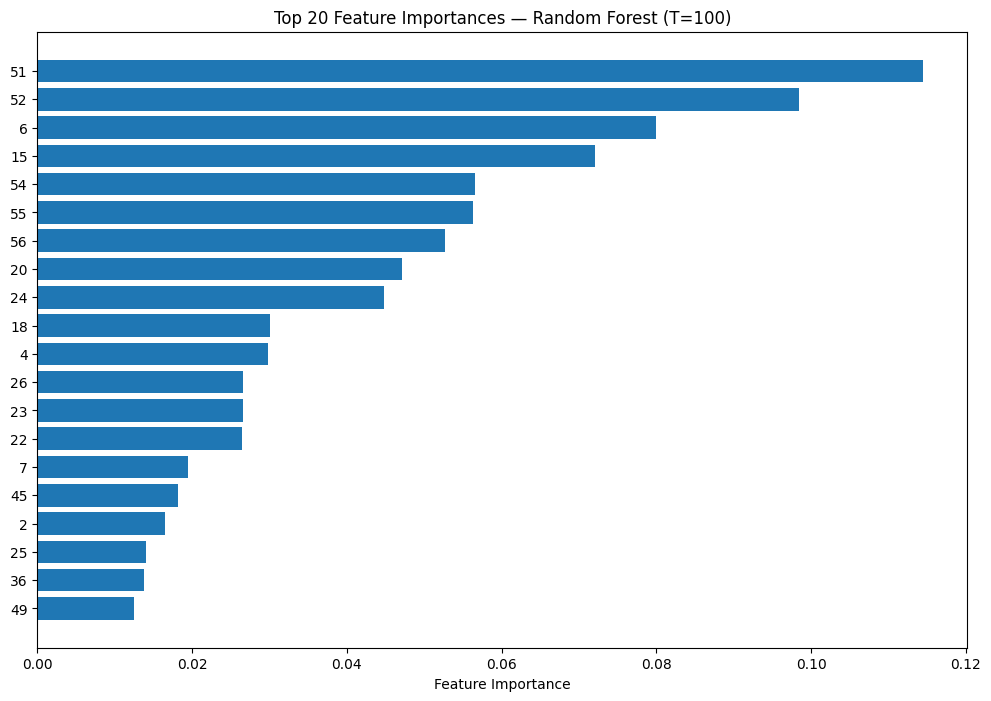

In [11]:
# 2.3

# Feature Importance using Random Forest with T=100

mod3 = mod_list[100]
importances = mod3.feature_importances_

feat_imp_df = pd.DataFrame({
    "Feature": range(len(importances)),
    "Importance": importances
}).sort_values("Importance", ascending=False)

print("Top 15 Most Important Features:")
print(feat_imp_df.head(15).to_string(index=False))

plt.figure(figsize=(12, 8))
top_feats = feat_imp_df.head(20)
plt.barh(range(20), top_feats["Importance"].values[::-1])
plt.yticks(range(20), top_feats["Feature"].values[::-1])
plt.xlabel("Feature Importance")
plt.title("Top 20 Feature Importances — Random Forest (T=100)")
plt.show()